# Objectives
I aim to compare the effectiveness of traditional forecasting models like Naive, Seasonal Naive, ARIMA, SARIMA, and SARIMAX and machine learning models like Decision Tree, Random Forest, XGBoost, and Neural Network. The comparison is implemented on sales data of Favorita stores located in Ecuador. The training data includes dates, store and product information, whether that item was being promoted, as well as the sales numbers. Additional files include supplementary information that may be useful in building your models.

# File Descriptions and Data Field Information

**train.csv**

- The training data, comprising time series of features `store_nbr`, `family`, and `onpromotion` as well as the target sales.
- `store_nbr` identifies the store at which the products are sold.
- `family` identifies the type of product sold.
- `sales` gives the total sales for a product family at a particular store at a given date. Fractional values are possible since products can be sold in fractional units (1.5 kg of cheese, for instance, as opposed to 1 bag of chips).
- `onpromotion` gives the total number of items in a product family that were being promoted at a store at a given date.

----------------------------------------------

**test.csv**

- The test data, having the same features as the training data.
- The dates in the test data are for the 15 days after the last date in the training data.

----------------------------------------------

**stores.csv**

- Store metadata, including `city`, `state`, `type`, and `cluster`.
- `cluster` is a grouping of similar stores.

----------------------------------------------

**oil.csv**

- Daily oil price. Includes values during both the train and test data timeframes. (Ecuador is an oil-dependent country and it's economical health is highly vulnerable to shocks in oil prices.)

----------------------------------------------

**holidays_events.csv**

- Holidays and Events, with metadata
- **NOTE:** Pay special attention to the `transferred` column. A holiday that is `transferred` officially falls on that calendar day, but was moved to another date by the government. A `transferred` day is more like a normal day than a holiday. To find the day that it was actually celebrated, look for the corresponding row where type is Transfer. For example, the holiday Independencia de Guayaquil was `transferred` from 2012-10-09 to 2012-10-12, which means it was celebrated on 2012-10-12. Days that are type Bridge are extra days that are added to a holiday (e.g., to extend the break across a long weekend). These are frequently made up by the type Work Day which is a day not normally scheduled for work (e.g., Saturday) that is meant to payback the Bridge.
- Additional holidays are days added a regular calendar holiday, for example, as typically happens around Christmas (making Christmas Eve a holiday).

**Additional Notes**

- Wages in the public sector are paid every two weeks on the 15th and on the last day of the month. Demand could be affected by this.
- A magnitude 7.8 earthquake struck Ecuador on April 16, 2016. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

# Citation
Alexis Cook, DanB, inversion, and Ryan Holbrook. Store Sales - Time Series Forecasting. https://kaggle.com/competitions/store-sales-time-series-forecasting, 2021. Kaggle.

In [1]:
import os
import numpy as np # mathematic calculations
import pandas as pd # exploratory data analysis
import scipy.stats as stats # statistics
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
import datetime as dt # date data manipulation
import time # training and predicting time recording
import ast
import joblib

# Import Time Series Analysis libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import ARIMA, SARIMAX

# Libraries for Machine Learning Models
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_log_error
import category_encoders as ce

# Neural Network
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from keras.models import Model
import keras_tuner as kt
from scikeras.wrappers import KerasRegressor
from scipy.stats import loguniform, randint, uniform

In [2]:
MAIN = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System'
RESULT = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/'
MODELS = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/models/'
DATA = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/data/'

In [3]:
df = pd.read_csv(DATA + 'weekly_features.csv')
df

,family,date,sales,onpromotion,holiday_count,is_holiday_week,max_days_since_earthquake,avg_oil_price,total_week_number,month,...,year,lag_1,lag_2,lag_3,lag_4,lag_12,lag_13,rolling_mean_4,rolling_mean_8,rolling_std_4
0,AUTOMOTIVE,2013-01-06,1287.000000,0,6,True,0,93.101667,1,1,...,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AUTOMOTIVE,2013-01-13,1514.000000,0,7,True,0,93.442857,2,1,...,2013,1287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AUTOMOTIVE,2013-01-20,1511.000000,0,7,True,0,94.875714,3,1,...,2013,1514.000000,1287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AUTOMOTIVE,2013-01-27,1517.000000,0,7,True,0,95.365714,4,1,...,2013,1511.000000,1514.000000,1287.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,AUTOMOTIVE,2013-02-03,1807.000000,0,7,True,0,97.368571,5,2,...,2013,1517.000000,1511.000000,1514.000000,1287.000000,NaN,NaN,1457.250000,NaN,113.526429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7981,SEAFOOD,2017-07-23,7454.984004,293,7,True,0,46.227143,238,7,...,2017,7341.093000,9596.762995,8310.072991,10654.591017,7414.232996,7809.619000,8975.630001,8316.651625,1451.366440
7982,SEAFOOD,2017-07-30,7314.220009,233,7,True,0,48.681429,239,7,...,2017,7454.984004,7341.093000,9596.762995,8310.072991,9847.812985,7414.232996,8175.728247,8158.234124,1041.389540
7983,SEAFOOD,2017-08-06,8209.558007,190,7,True,0,49.534286,240,8,...,2017,7314.220009,7454.984004,7341.093000,9596.762995,8494.228007,9847.812985,7926.765002,8047.334500,1115.002791
7984,SEAFOOD,2017-08-13,7110.504011,180,7,True,0,49.000000,241,8,...,2017,8209.558007,7314.220009,7454.984004,7341.093000,9514.000997,8494.228007,7579.963755,8198.383876,424.141422


/var/folders/pz/dvzlv8td7sqcf8m7zn92r2_80000gn/T/ipykernel_71572/333541380.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_sales.values, y=corr_with_sales.index, palette='viridis')


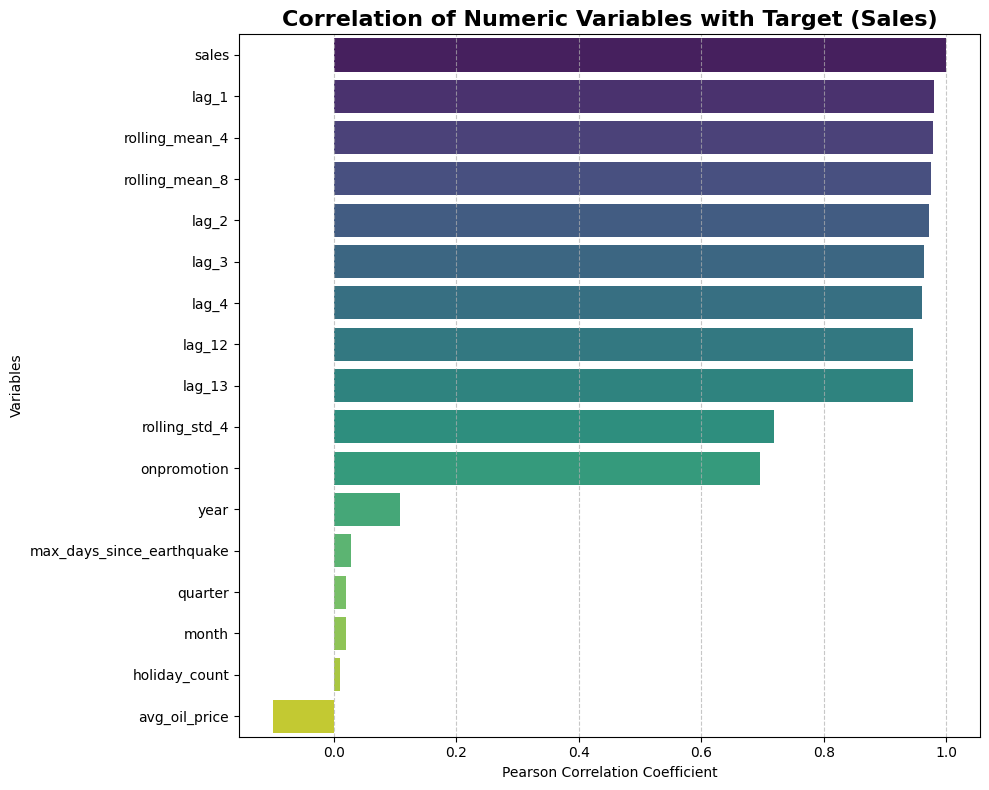

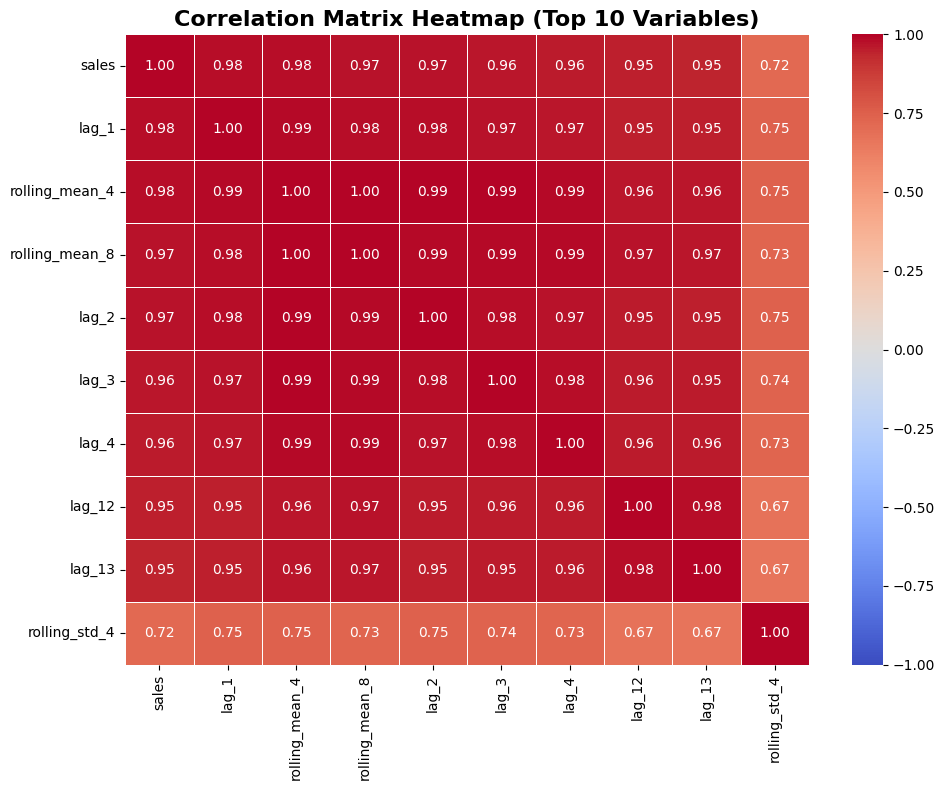

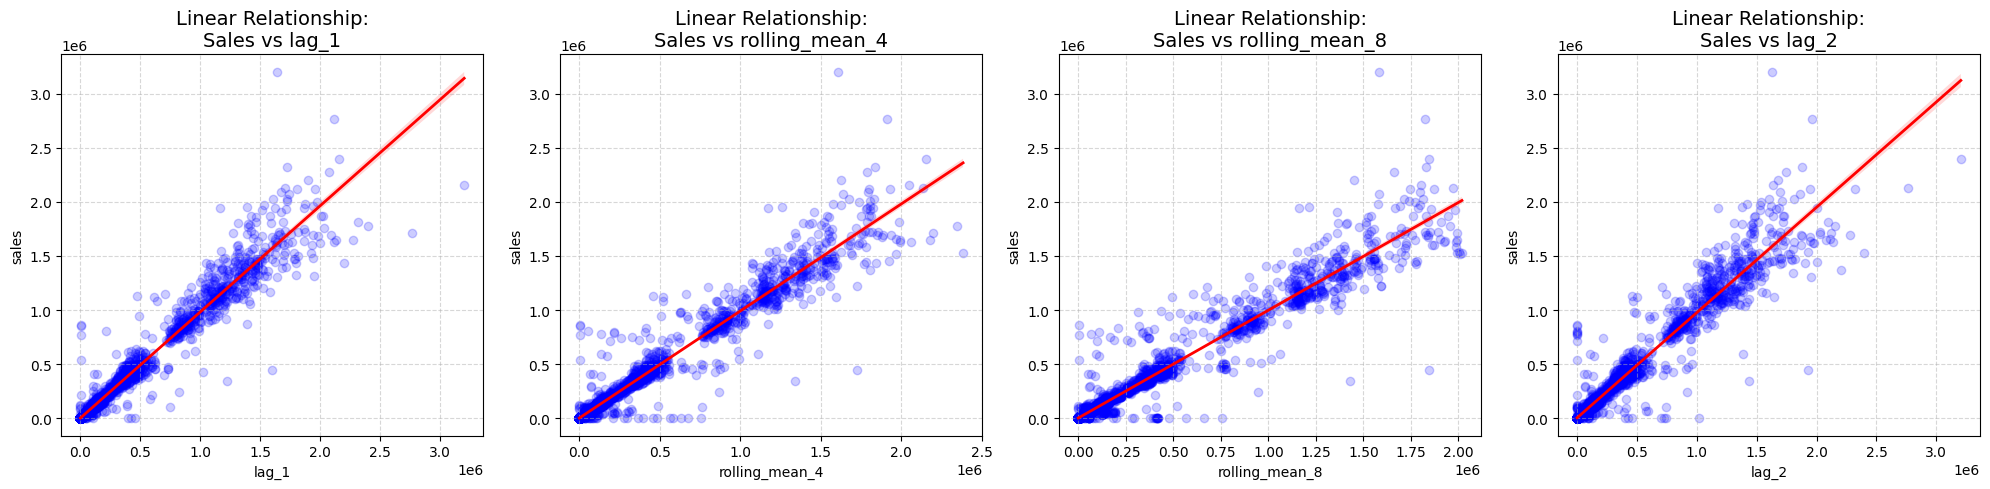

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the output directory exists inside the RESULT path
plot_dir = os.path.join(RESULT, 'dashboard_plots')
os.makedirs(plot_dir, exist_ok=True)

# ---------------------------------------------------------
# 1. Calculate Correlations
# ---------------------------------------------------------
# Select only numeric columns to avoid errors with dates or strings
numeric_df = df.drop(columns=['total_week_number']).select_dtypes(include=[np.number])

# Calculate correlation of all numeric variables specifically against 'sales'
corr_with_sales = numeric_df.corr()['sales'].sort_values(ascending=False)

# Plot 1: Bar chart of Correlations with Sales
fig_bar = plt.figure(figsize=(10, 8))
sns.barplot(x=corr_with_sales.values, y=corr_with_sales.index, palette='viridis')
plt.title("Correlation of Numeric Variables with Target (Sales)", fontsize=16, fontweight='bold')
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Variables")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and show
fig_bar.savefig(os.path.join(plot_dir, 'sales_correlations_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 2. Correlation Heatmap
# ---------------------------------------------------------
# Let's take the top 10 most highly correlated features (absolute value) to keep the heatmap readable
top_features = corr_with_sales.abs().nlargest(10).index

fig_heat = plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap (Top 10 Variables)", fontsize=16, fontweight='bold')
plt.tight_layout()

# Save and show
fig_heat.savefig(os.path.join(plot_dir, 'top_features_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 3. Linear Relationships (Scatter Plots)
# ---------------------------------------------------------
# Extract the top 4 most correlated features (excluding 'sales' itself)
features_to_plot = [feat for feat in top_features if feat != 'sales'][:4]

# Create a row of scatter plots with linear regression lines
fig_scatter, axes = plt.subplots(1, len(features_to_plot), figsize=(20, 5))

for i, feature in enumerate(features_to_plot):
    # regplot draws a scatter plot plus a linear regression line
    sns.regplot(data=df.drop(columns=['total_week_number']), x=feature, y='sales', ax=axes[i], 
                scatter_kws={'alpha':0.2, 'color': 'blue'}, 
                line_kws={'color': 'red', 'linewidth': 2})
    
    axes[i].set_title(f"Linear Relationship:\nSales vs {feature}", fontsize=14)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save and show
fig_scatter.savefig(os.path.join(plot_dir, 'top_features_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()

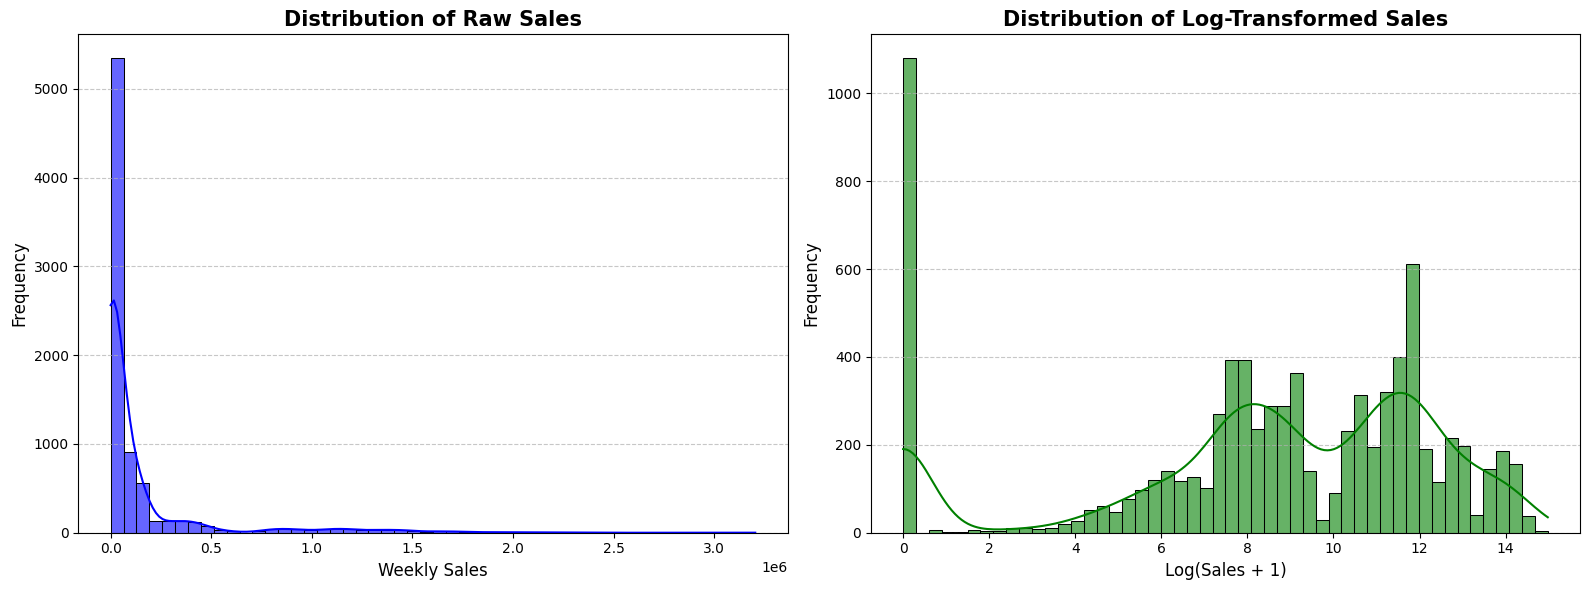

In [5]:
# Create the log-transformed target
# We use log1p (log(1 + x)) instead of log() to safely handle any weeks where sales were exactly 0
df['log_sales'] = np.log1p(df['sales'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: Raw Sales Distribution
# ---------------------------------------------------------
sns.histplot(df['sales'], bins=50, kde=True, ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title('Distribution of Raw Sales', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Weekly Sales', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# Plot 2: Log-Transformed Sales
# ---------------------------------------------------------
sns.histplot(df['log_sales'], bins=50, kde=True, ax=axes[1], color='green', alpha=0.6)
axes[1].set_title('Distribution of Log-Transformed Sales', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Log(Sales + 1)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save the plot to your dashboard folder
save_path = os.path.join(plot_dir, 'sales_distribution_comparison.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()


# Data Setup for Modeling

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Drop rows with NaNs (caused by lag features missing past data)
model_df = df.dropna().copy()

# 2. Filter for TOP 10 Families
top_10_families = model_df.groupby('family')['sales'].sum().nlargest(10).index.tolist()
model_df = model_df[model_df['family'].isin(top_10_families)].copy()

# Ensure 'date' is a datetime object, set it as index, and sort chronologically
if 'date' in model_df.columns:
    model_df['date'] = pd.to_datetime(model_df['date'])
    model_df = model_df.set_index('date').sort_index()

# ---------------------------------------------------------
# Preprocessing: Categorical Variables
# ---------------------------------------------------------
# CRITICAL: Save the original family names for our Recursive/Direct loops
model_df['original_family'] = model_df['family']

# Convert text columns into binary 0/1 columns
model_df = pd.get_dummies(model_df, columns=['family'], drop_first=True)
X_cols = [col for col in model_df.columns if col not in ['sales', 'log_sales', 'original_family']]

# ---------------------------------------------------------
# Train / Validation Split
# ---------------------------------------------------------
unique_dates = model_df.index.unique().sort_values()
FORECAST_HORIZON = 4  
cutoff_date = unique_dates[-FORECAST_HORIZON] # Reserve the last 4 weeks

train_df = model_df.loc[model_df.index < cutoff_date]
valid_df = model_df.loc[model_df.index >= cutoff_date]

# =========================================================
# Datasets Extraction
# =========================================================
X_train_ml = train_df[X_cols].astype(float)
y_train_ml = train_df['sales'].astype(float)
X_valid_ml = valid_df[X_cols].astype(float)
y_valid_ml = valid_df['sales'].astype(float)

X_train_dl = train_df[X_cols].astype(float)
y_train_dl = train_df['log_sales'].astype(float)
X_valid_dl = valid_df[X_cols].astype(float)
y_valid_dl = valid_df['log_sales'].astype(float)

# Scale continuous columns for Deep Learning
continuous_cols = [col for col in X_cols if X_train_dl[col].nunique() > 2]
scaler = StandardScaler()
X_train_dl[continuous_cols] = scaler.fit_transform(X_train_dl[continuous_cols])
X_valid_dl[continuous_cols] = scaler.transform(X_valid_dl[continuous_cols])

print(f"--- Machine Learning Datasets ---")
print(f"Training   (ML): X={X_train_ml.shape}, y={y_train_ml.shape}")
print(f"Validation (ML): X={X_valid_ml.shape}, y={y_valid_ml.shape}")

print(f"\n--- Deep Learning Datasets ---")
print(f"Training   (DL): X={X_train_dl.shape}, y={y_train_dl.shape}")
print(f"Validation (DL): X={X_valid_dl.shape}, y={y_valid_dl.shape}")

--- Machine Learning Datasets ---
Training   (ML): X=(7293, 50), y=(7293,)
Validation (ML): X=(264, 50), y=(264,)

--- Deep Learning Datasets ---
Training   (DL): X=(7293, 50), y=(7293,)
Validation (DL): X=(264, 50), y=(264,)


# Model Setup

In [ ]:
import time
import numpy as np
import pandas as pd

# ML Imports
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# PyTorch (DL) Imports
import torch
import torch.nn as nn
import torch.optim as optim

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Master list to track evaluation results and training times
ml_dl_results = []

# =========================================================
# 1. Initialize Machine Learning Models
# =========================================================
ml_models = {
    'Decision Tree (Base)': DecisionTreeRegressor(random_state=42),
    'Random Forest (Base)': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boost (Adv)': GradientBoostingRegressor(random_state=42),
    'XGBoost (Adv)': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')
}

# =========================================================
# 2. Setup Deep Learning Models (PyTorch)
# =========================================================
class BasicNN(nn.Module):
    """Base DL Model: Standard Multi-Layer Perceptron (MLP)"""
    def __init__(self, input_dim):
        super(BasicNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(32, 1) # Linear output for regression

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.out(x)

class LSTMModel(nn.Module):
    """Advanced DL Model: Long Short-Term Memory Network"""
    def __init__(self, input_dim):
        super(LSTMModel, self).__init__()
        # batch_first=True means input shape should be (batch, time_steps, features)
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=64, batch_first=True)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        # x shape: (batch_size, time_steps=1, features)
        lstm_out, _ = self.lstm(x)
        
        # Extract the output of the final time step
        last_out = lstm_out[:, -1, :]
        
        x = self.relu(self.fc1(last_out))
        return self.out(x)

def train_pytorch_model(model, X_train, y_train, epochs=20, lr=0.005, is_lstm=False):
    # 1. Automatically detect the best available hardware
    if torch.cuda.is_available():
        device = torch.device("cuda") # Google Colab NVIDIA GPU
    elif torch.backends.mps.is_available():
        device = torch.device("mps")  # Apple Silicon Mac GPU
    else:
        device = torch.device("cpu")  # Standard Fallback

    # Move model to the fast hardware for training
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 2. Convert Pandas data to Tensors and move them to the fast hardware
    X_tensor = torch.FloatTensor(X_train.values).to(device)
    y_tensor = torch.FloatTensor(y_train.values).view(-1, 1).to(device)
    
    if is_lstm:
        X_tensor = X_tensor.unsqueeze(1)
        
    # 3. Fast Training Loop
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(X_tensor)
        loss = criterion(predictions, y_tensor)
        loss.backward()
        optimizer.step()
        
    # 4. CRITICAL: Move model back to CPU after training!
    # This ensures the Recursive and Direct inference loops don't crash later 
    # when they try to feed normal CPU data into the model.
    model.to('cpu')
    
    return model

# =========================================================
# 3. Helper: Direct Forecasting Setup
# =========================================================
def prepare_direct_target(y_train, steps_ahead):
    """
    Shifts the target backwards to facilitate Direct Forecasting.
    If steps_ahead=2, the model learns to map today's features to the sales 2 weeks from now.
    """
    y_shifted = y_train.shift(-steps_ahead)
    valid_indices = y_shifted.notna()
    return y_shifted[valid_indices], valid_indices


# =========================================================
# 4. Helper: Recursive Forecasting Update Logic
# =========================================================
def update_features_for_next_step(current_row, new_prediction):
    """
    During Recursive inference, you loop through X_test one row at a time.
    After predicting Week 1, you must use this function to inject the prediction 
    into the lag features of Week 2 before predicting Week 2.
    """
    next_row = current_row.copy()
    
    # Shift historical lags down
    if 'lag_4' in next_row and 'lag_3' in next_row:
        next_row['lag_4'] = next_row['lag_3']
    if 'lag_3' in next_row and 'lag_2' in next_row:
        next_row['lag_3'] = next_row['lag_2']
    if 'lag_2' in next_row and 'lag_1' in next_row:
        next_row['lag_2'] = next_row['lag_1']
        
    # Inject the brand new prediction as the most recent lag
    if 'lag_1' in next_row:
        next_row['lag_1'] = new_prediction
        
    # Recalculate rolling features based on the new lags
    if 'rolling_mean_4' in next_row:
        next_row['rolling_mean_4'] = (next_row['lag_1'] + next_row['lag_2'] + 
                                      next_row['lag_3'] + next_row['lag_4']) / 4
        
    return next_row

In [ ]:
import copy
import torch

ml_dl_results = []
# Only test families that have a complete 4-week validation set!
valid_families = []
for fam in valid_df['original_family'].unique():
    if len(valid_df[valid_df['original_family'] == fam]) >= FORECAST_HORIZON:
        valid_families.append(fam)
        
top_10 = valid_families

if len(top_10) == 0:
    print("CRITICAL WARNING: No families have 4 weeks of validation data!")

# =========================================================
# 1. Train Base Recursive Models
# =========================================================
print("=== Training Models for Recursive Forecasting ===")
for name, model in ml_models.items():
    print(f"  -> Fitting {name}...")
    model.fit(X_train_ml, y_train_ml)

dl_models = {
    'Basic NN': {'model': BasicNN(X_train_dl.shape[1]), 'is_lstm': False},
    'LSTM': {'model': LSTMModel(X_train_dl.shape[1]), 'is_lstm': True}
}

for name, info in dl_models.items():
    print(f"  -> Fitting {name}...")
    train_pytorch_model(info['model'], X_train_dl, y_train_dl, epochs=20, lr=0.005, is_lstm=info['is_lstm'])

# =========================================================
# 2. Recursive Inference Loop
# =========================================================
print("\n=== Running Recursive Inference (Predicting 4 weeks) ===")

# Dictionaries to track predictions across all families
all_preds_recursive = {name: [] for name in list(ml_models.keys()) + list(dl_models.keys())}
actual_sales_valid = [] # We collect this once to compare against later

for fam in top_10:
    # Filter validation data strictly for this family (first 4 weeks only)
    fam_valid_raw = valid_df[valid_df['family'] == fam].iloc[:FORECAST_HORIZON].copy()
    actual_sales_valid.extend(fam_valid_raw['sales'].values)
    
    # ML Models Inference
    for name, model in ml_models.items():
        current_row = fam_valid_raw[X_cols].iloc[0].copy().astype(float)
        
        for step in range(len(fam_valid_raw)):
            pred = model.predict(current_row.values.reshape(1, -1))[0]
            all_preds_recursive[name].append(pred)
            
            # Inject prediction into the next week's lags
            if step + 1 < len(fam_valid_raw):
                next_row = fam_valid_raw[X_cols].iloc[step + 1].copy().astype(float)
                current_row = update_features_for_next_step(next_row, pred)
                
    # DL Models Inference (Requires On-the-Fly Scaling!)
    for name, info in dl_models.items():
        pt_model = info['model']
        pt_model.eval()
        
        current_row = fam_valid_raw[X_cols].iloc[0].copy().astype(float)
        
        with torch.no_grad():
            for step in range(len(fam_valid_raw)):
                # Scale the current row dynamically
                row_df = pd.DataFrame([current_row], columns=X_cols)
                row_df[continuous_cols] = scaler.transform(row_df[continuous_cols])
                
                x_tensor = torch.FloatTensor(row_df.values)
                if info['is_lstm']: x_tensor = x_tensor.unsqueeze(1)
                    
                log_pred = pt_model(x_tensor).item()
                log_pred = np.clip(log_pred, 0, 20)
                real_pred = np.expm1(log_pred) # Convert back to real sales
                all_preds_recursive[name].append(real_pred)
                
                # Inject REAL sales into the raw next row so the lags stay mathematically correct
                if step + 1 < len(fam_valid_raw):
                    next_row = fam_valid_raw[X_cols].iloc[step + 1].copy().astype(float)
                    current_row = update_features_for_next_step(next_row, real_pred)

# 3. Save Results
for model_name, preds in all_preds_recursive.items():
    
    # Grab the correct parameter string
    if model_name in ml_models:
        params_str = str(ml_models[model_name].get_params())
    elif model_name == 'Basic NN':
        params_str = "Epochs: 20 | LR: 0.005 | Architecture: [Input -> Linear(64) -> ReLU -> Linear(32) -> ReLU -> Linear(1)]"
    else: # LSTM
        params_str = "Epochs: 20 | LR: 0.005 | Architecture: [Input(time_steps=1) -> LSTM(hidden_size=64) -> Extract Last Step -> ReLU -> Linear(32) -> Linear(1)]"
    
    ml_dl_results.append({
        'Model': f"{model_name} (Recursive)",
        'Parameters': params_str,
        'MAE': mean_absolute_error(actual_sales_valid, preds),
        'RMSE': np.sqrt(mean_squared_error(actual_sales_valid, preds)),
        'MAPE': mean_absolute_percentage_error(actual_sales_valid, preds)
    })
print("Recursive loop finished!")

=== Training Models for Recursive Forecasting ===
  -> Fitting Decision Tree (Base)...
  -> Fitting Random Forest (Base)...
  -> Fitting Gradient Boost (Adv)...
  -> Fitting XGBoost (Adv)...
  -> Fitting Basic NN...


In [ ]:
print("=== Running Direct Forecasting ===")

# Create a matrix to cleanly store predictions: [Family Index, Horizon Step]
preds_direct_matrix = {name: np.zeros((len(top_10), FORECAST_HORIZON)) for name in list(ml_models.keys()) + list(dl_models.keys())}

for h in range(1, FORECAST_HORIZON + 1):
    print(f"\n--- Training Horizon h={h} ---")
    
    # 1. Shift targets safely within family boundaries
    y_train_ml_h = train_df.groupby('original_family')['sales'].shift(-(h-1))
    y_train_dl_h = train_df.groupby('original_family')['log_sales'].shift(-(h-1))
    
    valid_mask = y_train_ml_h.notna()
    
    X_train_ml_h = X_train_ml[valid_mask]
    y_train_ml_h = y_train_ml_h[valid_mask]
    X_train_dl_h = X_train_dl[valid_mask]
    y_train_dl_h = y_train_dl_h[valid_mask]
    
    # 2. Train New ML Models
    ml_h_models = copy.deepcopy(ml_models)
    for name, model in ml_h_models.items():
        model.fit(X_train_ml_h, y_train_ml_h)
        
    # 3. Train New DL Models
    dl_h_models = {
        'Basic NN': {'model': BasicNN(X_train_dl.shape[1]), 'is_lstm': False},
        'LSTM': {'model': LSTMModel(X_train_dl.shape[1]), 'is_lstm': True}
    }
    for name, info in dl_h_models.items():
        train_pytorch_model(info['model'], X_train_dl_h, y_train_dl_h, epochs=20, lr=0.005, is_lstm=info['is_lstm'])
        
    # ----------------------------------------------------
    # Inference for horizon step `h`
    # ----------------------------------------------------
    # For horizon h, we ONLY predict the (h-1)th row of the validation set for each family
    for f_idx, fam in enumerate(top_10):
        fam_valid_raw = valid_df[valid_df['original_family'] == fam]
        row_h_raw = fam_valid_raw[X_cols].iloc[h-1].copy().astype(float)
        
        # ML Inference
        for name, model in ml_h_models.items():
            pred = model.predict(row_h_raw.values.reshape(1, -1))[0]
            preds_direct_matrix[name][f_idx, h-1] = pred
            
        # DL Inference
        for name, info in dl_h_models.items():
            pt_model = info['model']
            pt_model.eval()
            with torch.no_grad():
                row_df = pd.DataFrame([row_h_raw], columns=X_cols)
                row_df[continuous_cols] = scaler.transform(row_df[continuous_cols])
                x_tensor = torch.FloatTensor(row_df.values)
                if info['is_lstm']: x_tensor = x_tensor.unsqueeze(1)
                
                log_pred = pt_model(x_tensor).item()
                log_pred = np.clip(log_pred, 0, 20)
                real_pred = np.expm1(log_pred)
                preds_direct_matrix[name][f_idx, h-1] = real_pred

# Flatten the prediction matrices so they align perfectly with the `actual_sales_valid` tracking list
for name in preds_direct_matrix.keys():
    flattened_preds = preds_direct_matrix[name].flatten()
    
    # Grab the correct parameter string
    if name in ml_models:
        params_str = str(ml_models[name].get_params())
    elif name == 'Basic NN':
        params_str = "Epochs: 20 | LR: 0.005 | Architecture: [Input -> Linear(64) -> ReLU -> Linear(32) -> ReLU -> Linear(1)]"
    else: # LSTM
        params_str = "Epochs: 20 | LR: 0.005 | Architecture: [Input(time_steps=1) -> LSTM(hidden_size=64) -> Extract Last Step -> ReLU -> Linear(32) -> Linear(1)]"
        
    ml_dl_results.append({
        'Model': f"{name} (Direct)",
        'Parameters': params_str,
        'MAE': mean_absolute_error(actual_sales_valid, flattened_preds),
        'RMSE': np.sqrt(mean_squared_error(actual_sales_valid, flattened_preds)),
        'MAPE': mean_absolute_percentage_error(actual_sales_valid, flattened_preds)
    })

# =========================================================
# Display Final Comparison
# =========================================================
overall_model_comparison = pd.DataFrame(ml_dl_results)

print("\n" + "="*60)
print("OVERALL MODEL COMPARISON: RECURSIVE VS DIRECT")
print("="*60)
display(overall_model_comparison.sort_values('RMSE'))

In [ ]:
import copy
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid

# ===================================================================
# 1. Dynamically Tunable Deep Learning Models
# ===================================================================
class TunableBasicNN(nn.Module):
    def __init__(self, input_dim, hidden_1=64, hidden_2=32):
        super(TunableBasicNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(hidden_2, 1)

    def forward(self, x):
        return self.out(self.relu2(self.fc2(self.relu1(self.fc1(x)))))

class TunableLSTM(nn.Module):
    def __init__(self, input_dim, hidden_lstm=64, hidden_fc=32):
        super(TunableLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_lstm, batch_first=True)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(hidden_lstm, hidden_fc)
        self.out = nn.Linear(hidden_fc, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :] # Extract last time step
        return self.out(self.relu(self.fc1(last_out)))

# ===================================================================
# 2. Recursive Evaluation Helper
# ===================================================================
def evaluate_recursive(model, is_dl=False, is_lstm=False):
    """Evaluates a single model using the custom Recursive loop on Top 10 families."""
    all_preds = []
    actuals = []
    
    for fam in top_10:
        fam_valid_raw = valid_df[valid_df['original_family'] == fam].iloc[:FORECAST_HORIZON].copy()
        actuals.extend(fam_valid_raw['sales'].values)
        
        if not is_dl: # Machine Learning Inference
            current_row = fam_valid_raw[X_cols].iloc[0].copy().astype(float)
            for step in range(len(fam_valid_raw)):
                pred = model.predict(current_row.values.reshape(1, -1))[0]
                all_preds.append(pred)
                if step + 1 < len(fam_valid_raw):
                    next_row = fam_valid_raw[X_cols].iloc[step + 1].copy().astype(float)
                    current_row = update_features_for_next_step(next_row, pred)
        else: # Deep Learning Inference
            model.eval()
            current_row = fam_valid_raw[X_cols].iloc[0].copy().astype(float)
            with torch.no_grad():
                for step in range(len(fam_valid_raw)):
                    row_df = pd.DataFrame([current_row], columns=X_cols)
                    row_df[continuous_cols] = scaler.transform(row_df[continuous_cols])
                    x_tensor = torch.FloatTensor(row_df.values)
                    if is_lstm: x_tensor = x_tensor.unsqueeze(1)
                    
                    log_pred = model(x_tensor).item()
                    log_pred = np.clip(log_pred, 0, 20) # Prevent Infinity Explosion
                    real_pred = np.expm1(log_pred)
                    all_preds.append(real_pred)
                    
                    if step + 1 < len(fam_valid_raw):
                        next_row = fam_valid_raw[X_cols].iloc[step + 1].copy().astype(float)
                        current_row = update_features_for_next_step(next_row, real_pred)
                        
    return np.sqrt(mean_squared_error(actuals, all_preds)), all_preds, actuals

# ===================================================================
# 3. Dynamic Boundary-Shifting Tuning Engine
# ===================================================================
def dynamic_grid_search(model_name, model_class, initial_grid, is_dl=False, is_lstm=False):
    print(f"\n[{model_name}] Starting Tuning...")
    current_grid = copy.deepcopy(initial_grid)
    
    global_best_rmse = float('inf')
    global_best_params = None
    global_best_preds = None
    global_actuals = None
    
    evaluated_params = set() # Prevent testing the same params twice
    
    while True:
        improved_in_this_loop = False
        param_combinations = list(ParameterGrid(current_grid))
        
        for params in param_combinations:
            # Hash to check if evaluated
            param_hash = str(sorted(params.items()))
            if param_hash in evaluated_params: continue
            evaluated_params.add(param_hash)
            
            try:
                # --- Train Model ---
                if not is_dl:
                    model = model_class(**params)
                    model.fit(X_train_ml, y_train_ml)
                else:
                    epochs = params.pop('epochs', 20)
                    lr = params.pop('lr', 0.005)
                    model = model_class(X_train_dl.shape[1], **params)
                    train_pytorch_model(model, X_train_dl, y_train_dl, epochs=epochs, lr=lr, is_lstm=is_lstm)
                    # Put params back for saving
                    params['epochs'] = epochs; params['lr'] = lr
                    
                # --- Evaluate Model ---
                rmse, preds, actuals = evaluate_recursive(model, is_dl=is_dl, is_lstm=is_lstm)
                print(f"  Tested {params} -> RMSE: {rmse:.2f}")
                
                if rmse < global_best_rmse:
                    global_best_rmse = rmse
                    global_best_params = copy.deepcopy(params)
                    global_best_preds = preds
                    global_actuals = actuals
                    improved_in_this_loop = True
            except Exception as e:
                # Catch invalid parameters safely
                print(f"  Skipping {params} (Invalid)")
                
        # If no new combinations beat the old score, stop searching!
        if not improved_in_this_loop:
            print(f"[{model_name}] No boundary improvements. Stopping shift.")
            break
            
        # --- Shift Boundaries Logic ---
        shifted = False
        for param_key, param_list in current_grid.items():
            # Only shift arrays of integers that have length >= 2
            if isinstance(param_list, list) and len(param_list) >= 2 and all(isinstance(i, int) for i in param_list):
                best_val = global_best_params[param_key]
                
                # Calculate the exact shift needed to make the boundary the new "middle"
                shift_amount = (max(param_list) - min(param_list)) // 2
                if shift_amount == 0: 
                    shift_amount = 1 # Prevent getting stuck if the gap is very small
                
                # 1. RIGHT EDGE HIT
                if best_val == max(param_list):
                    print(f"  --> {param_key} hit RIGHT boundary ({best_val}). Shifting grid up by {shift_amount}!")
                    current_grid[param_key] = [val + shift_amount for val in param_list]
                    shifted = True
                    
                # 2. LEFT EDGE HIT
                elif best_val == min(param_list):
                    if min(param_list) - shift_amount > 0: # Don't shift into 0 or negatives
                        print(f"  --> {param_key} hit LEFT boundary ({best_val}). Shifting grid down by {shift_amount}!")
                        current_grid[param_key] = [val - shift_amount for val in param_list]
                        shifted = True
                        
        if not shifted:
            break # No boundaries were hit, so the tuning is complete!
            
    print(f"[{model_name}] Best Params: {global_best_params} | Best RMSE: {global_best_rmse:.2f}")
    
    mae = mean_absolute_error(global_actuals, global_best_preds)
    mape = mean_absolute_percentage_error(global_actuals, global_best_preds)
    
    return global_best_params, mae, global_best_rmse, mape

# ===================================================================
# 4. Define Search Spaces and Run
# ===================================================================
models_to_tune = [
    {'name': 'Decision Tree (Tuned)', 'class': DecisionTreeRegressor, 'grid': {'max_depth': [5, 10]}, 'is_dl': False, 'is_lstm': False},
    {'name': 'Random Forest (Tuned)', 'class': RandomForestRegressor, 'grid': {'max_depth': [10, 15], 'n_estimators': [50, 100]}, 'is_dl': False, 'is_lstm': False},
    {'name': 'Gradient Boost (Tuned)', 'class': GradientBoostingRegressor, 'grid': {'max_depth': [3, 5], 'n_estimators': [50, 100]}, 'is_dl': False, 'is_lstm': False},
    {'name': 'XGBoost (Tuned)', 'class': XGBRegressor, 'grid': {'max_depth': [3, 5], 'n_estimators': [50, 100]}, 'is_dl': False, 'is_lstm': False},
    {'name': 'Basic NN (Tuned)', 'class': TunableBasicNN, 'grid': {'hidden_1': [32, 64], 'hidden_2': [16, 32]}, 'is_dl': True, 'is_lstm': False},
    {'name': 'LSTM (Tuned)', 'class': TunableLSTM, 'grid': {'hidden_lstm': [32, 64], 'hidden_fc': [16, 32]}, 'is_dl': True, 'is_lstm': True}
]

tuned_results = []

for m in models_to_tune:
    best_params, mae, rmse, mape = dynamic_grid_search(
        m['name'], m['class'], m['grid'], is_dl=m['is_dl'], is_lstm=m['is_lstm']
    )
    tuned_results.append({
        'Model': m['name'],
        'Parameters': str(best_params),
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    })

tuned_model_comparison = pd.DataFrame(tuned_results)
print("\n" + "="*50)
print("TUNED MODELS COMPARISON")
print("="*50)
display(tuned_model_comparison.sort_values('RMSE'))


In [ ]:
import copy
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid

# ===================================================================
# 1. Direct Evaluation Helper
# ===================================================================
def evaluate_direct(model_class, params, is_dl=False, is_lstm=False):
    """Evaluates a parameter combination by training H separate models (Direct Method)"""
    all_preds_matrix = np.zeros((len(top_10), FORECAST_HORIZON))
    actuals = []
    
    # Collect chronological actuals for comparison
    for fam in top_10:
        fam_valid_raw = valid_df[valid_df['original_family'] == fam].iloc[:FORECAST_HORIZON]
        actuals.extend(fam_valid_raw['sales'].values)
            
    for h in range(1, FORECAST_HORIZON + 1):
        # Shift targets safely within family boundaries
        y_train_ml_h = train_df.groupby('original_family')['sales'].shift(-(h-1))
        y_train_dl_h = train_df.groupby('original_family')['log_sales'].shift(-(h-1))
        
        valid_mask = y_train_ml_h.notna()
        X_train_ml_h = X_train_ml[valid_mask]
        y_train_ml_h = y_train_ml_h[valid_mask]
        X_train_dl_h = X_train_dl[valid_mask]
        y_train_dl_h = y_train_dl_h[valid_mask]
        
        # Train Model for horizon `h`
        if not is_dl:
            model = model_class(**params)
            model.fit(X_train_ml_h, y_train_ml_h)
        else:
            epochs = params.get('epochs', 20)
            lr = params.get('lr', 0.005)
            # We must recreate a fresh Neural Network for every horizon step!
            model = model_class(X_train_dl.shape[1], **params)
            train_pytorch_model(model, X_train_dl_h, y_train_dl_h, epochs=epochs, lr=lr, is_lstm=is_lstm)
            model.eval()
            
        # Inference for step `h`
        for f_idx, fam in enumerate(top_10):
            fam_valid_raw = valid_df[valid_df['original_family'] == fam]
            row_h_raw = fam_valid_raw[X_cols].iloc[h-1].copy().astype(float)
            
            if not is_dl:
                pred = model.predict(row_h_raw.values.reshape(1, -1))[0]
                all_preds_matrix[f_idx, h-1] = pred
            else:
                with torch.no_grad():
                    row_df = pd.DataFrame([row_h_raw], columns=X_cols)
                    row_df[continuous_cols] = scaler.transform(row_df[continuous_cols])
                    x_tensor = torch.FloatTensor(row_df.values)
                    if is_lstm: x_tensor = x_tensor.unsqueeze(1)
                    
                    log_pred = model(x_tensor).item()
                    log_pred = np.clip(log_pred, 0, 20)
                    real_pred = np.expm1(log_pred)
                    all_preds_matrix[f_idx, h-1] = real_pred
                    
    flattened_preds = all_preds_matrix.flatten()
    return np.sqrt(mean_squared_error(actuals, flattened_preds)), flattened_preds, actuals


# ===================================================================
# 2. Dynamic Boundary-Shifting Tuning Engine (Direct)
# ===================================================================
def dynamic_grid_search_direct(model_name, model_class, initial_grid, is_dl=False, is_lstm=False):
    print(f"\n[{model_name}] Starting Direct Tuning...")
    current_grid = copy.deepcopy(initial_grid)
    
    global_best_rmse = float('inf')
    global_best_params = None
    global_best_preds = None
    global_actuals = None
    
    evaluated_params = set() 
    
    while True:
        improved_in_this_loop = False
        param_combinations = list(ParameterGrid(current_grid))
        
        for params in param_combinations:
            param_hash = str(sorted(params.items()))
            if param_hash in evaluated_params: continue
            evaluated_params.add(param_hash)
            
            try:
                # --- Evaluate Model (Trains 4 sub-models automatically) ---
                rmse, preds, actuals = evaluate_direct(model_class, params, is_dl=is_dl, is_lstm=is_lstm)
                print(f"  Tested {params} -> RMSE: {rmse:.2f}")
                
                if rmse < global_best_rmse:
                    global_best_rmse = rmse
                    global_best_params = copy.deepcopy(params)
                    global_best_preds = preds
                    global_actuals = actuals
                    improved_in_this_loop = True
            except Exception as e:
                print(f"  Skipping {params} (Invalid)")
                
        if not improved_in_this_loop:
            print(f"[{model_name}] No boundary improvements. Stopping shift.")
            break
            
        # --- Shift Boundaries Logic ---
        shifted = False
        for param_key, param_list in current_grid.items():
            if isinstance(param_list, list) and len(param_list) >= 2 and all(isinstance(i, int) for i in param_list):
                best_val = global_best_params[param_key]
                shift_amount = (max(param_list) - min(param_list)) // 2
                if shift_amount == 0: shift_amount = 1 
                
                if best_val == max(param_list):
                    print(f"  --> {param_key} hit RIGHT boundary ({best_val}). Shifting grid up by {shift_amount}!")
                    current_grid[param_key] = [val + shift_amount for val in param_list]
                    shifted = True
                elif best_val == min(param_list):
                    if min(param_list) - shift_amount > 0: 
                        print(f"  --> {param_key} hit LEFT boundary ({best_val}). Shifting grid down by {shift_amount}!")
                        current_grid[param_key] = [val - shift_amount for val in param_list]
                        shifted = True
                        
        if not shifted:
            break 
            
    print(f"[{model_name}] Best Params: {global_best_params} | Best RMSE: {global_best_rmse:.2f}")
    
    mae = mean_absolute_error(global_actuals, global_best_preds)
    mape = mean_absolute_percentage_error(global_actuals, global_best_preds)
    
    return global_best_params, mae, global_best_rmse, mape

# ===================================================================
# 3. Run the Direct Tuner
# ===================================================================
tuned_direct_results = []

for m in models_to_tune:
    best_params, mae, rmse, mape = dynamic_grid_search_direct(
        m['name'], m['class'], m['grid'], is_dl=m['is_dl'], is_lstm=m['is_lstm']
    )
    tuned_direct_results.append({
        'Model': m['name'] + " (Direct)",
        'Parameters': str(best_params),
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    })

tuned_direct_comparison = pd.DataFrame(tuned_direct_results)
print("\n" + "="*50)
print("TUNED DIRECT MODELS COMPARISON")
print("="*50)
display(tuned_direct_comparison.sort_values('RMSE'))


In [ ]:
# 1. Add " (Recursive)" to the model names in the first dataframe
tuned_model_comparison['Model'] = tuned_model_comparison['Model'] + " (Recursive)"

# 2. Stack them vertically into one master DataFrame
tuned_model_comparison = pd.concat([tuned_model_comparison, tuned_direct_comparison], ignore_index=True)

# 3. Display the final, combined results sorted by best RMSE
print("\n" + "="*70)
print("FINAL MASTER COMPARISON: ALL TUNED MODELS (Recursive & Direct)")
print("="*70)
display(tuned_model_comparison.sort_values('RMSE'))

In [ ]:
tuned_model_comparison.to_csv(os.path.join(MODELS, 'tuned_ml_dl_model_performance.csv'), index=False)

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Ensure the output directory exists
plot_dir = os.path.join(RESULT, 'dashboard_plots')
os.makedirs(plot_dir, exist_ok=True)

# 1. Get the best overall model from the tuning comparison
best_model_row = tuned_model_comparison.sort_values('RMSE').iloc[0]
full_model_name = best_model_row['Model']
params_str = best_model_row['Parameters']

print(f"=== Preparing Best ML/DL Model: {full_model_name} ===")

is_direct = "(Direct)" in full_model_name
base_model_name = full_model_name.replace(" (Recursive)", "").replace(" (Direct)", "")

# Find the class and flags
model_info = next(m for m in models_to_tune if m['name'] == base_model_name)
model_class = model_info['class']
is_dl = model_info['is_dl']
is_lstm = model_info['is_lstm']

# Parse parameters safely
try:
    best_params = ast.literal_eval(params_str)
except:
    best_params = {}

# ----------------------------------------------------
# 2. Train the Best Model(s) Globally ONCE
# ----------------------------------------------------
trained_models = {}

if not is_direct:
    print("Training Recursive Model...")
    if not is_dl:
        model = model_class(**best_params)
        model.fit(X_train_ml, y_train_ml)
        trained_models['recursive'] = model
    else:
        epochs = best_params.get('epochs', 20)
        lr = best_params.get('lr', 0.005)
        model = model_class(X_train_dl.shape[1], **best_params)
        train_pytorch_model(model, X_train_dl, y_train_dl, epochs=epochs, lr=lr, is_lstm=is_lstm)
        model.eval()
        trained_models['recursive'] = model
else:
    print("Training Direct Models (H steps)...")
    for h in range(1, FORECAST_HORIZON + 1):
        y_train_ml_h = train_df.groupby('original_family')['sales'].shift(-(h-1))
        y_train_dl_h = train_df.groupby('original_family')['log_sales'].shift(-(h-1))
        valid_mask = y_train_ml_h.notna()
        
        if not is_dl:
            model = model_class(**best_params)
            model.fit(X_train_ml[valid_mask], y_train_ml_h[valid_mask])
            trained_models[h] = model
        else:
            epochs = best_params.get('epochs', 20)
            lr = best_params.get('lr', 0.005)
            model = model_class(X_train_dl.shape[1], **best_params)
            train_pytorch_model(model, X_train_dl[valid_mask], y_train_dl_h[valid_mask], epochs=epochs, lr=lr, is_lstm=is_lstm)
            model.eval()
            trained_models[h] = model

# ----------------------------------------------------
# 3. Predict and Plot for each Family
# ----------------------------------------------------
for fam in top_10:
    print(f"Plotting {fam}...")
    
    # Get all historical data for the family (No tail truncation)
    fam_train = train_df[train_df['original_family'] == fam]
    fam_valid = valid_df[valid_df['original_family'] == fam].iloc[:FORECAST_HORIZON]
    
    # Get the exact ML/DL feature matrices for the training data
    X_train_ml_fam = X_train_ml[train_df['original_family'] == fam]
    X_train_dl_fam = X_train_dl[train_df['original_family'] == fam]
    
    hist_dates = fam_train['date'] if 'date' in fam_train.columns else fam_train.index
    hist_sales = fam_train['sales']
    
    val_dates = fam_valid['date'] if 'date' in fam_valid.columns else fam_valid.index
    val_sales = fam_valid['sales']
    
    y_pred_train = []
    y_pred_test = []
    
    if not is_direct:
        # RECURSIVE INFERENCE
        model = trained_models['recursive']
        
        # A) Calculate Fitted Values (Training Data)
        if not is_dl:
            y_pred_train = model.predict(X_train_ml_fam)
        else:
            with torch.no_grad():
                x_tensor = torch.FloatTensor(X_train_dl_fam.values)
                if is_lstm: x_tensor = x_tensor.unsqueeze(1)
                log_pred = model(x_tensor).numpy().flatten()
                log_pred = np.clip(log_pred, 0, 20)
                y_pred_train = np.expm1(log_pred)
                
        # B) Calculate Forecast Values (Validation Data)
        current_row = fam_valid[X_cols].iloc[0].copy().astype(float)
        
        if not is_dl:
            for step in range(len(fam_valid)):
                pred = model.predict(current_row.values.reshape(1, -1))[0]
                y_pred_test.append(pred)
                if step + 1 < len(fam_valid):
                    next_row = fam_valid[X_cols].iloc[step + 1].copy().astype(float)
                    current_row = update_features_for_next_step(next_row, pred)
        else:
            with torch.no_grad():
                for step in range(len(fam_valid)):
                    row_df = pd.DataFrame([current_row], columns=X_cols)
                    row_df[continuous_cols] = scaler.transform(row_df[continuous_cols])
                    x_tensor = torch.FloatTensor(row_df.values)
                    if is_lstm: x_tensor = x_tensor.unsqueeze(1)
                    
                    log_pred_test = model(x_tensor).item()
                    log_pred_test = np.clip(log_pred_test, 0, 20)
                    real_pred = np.expm1(log_pred_test)
                    y_pred_test.append(real_pred)
                    
                    if step + 1 < len(fam_valid):
                        next_row = fam_valid[X_cols].iloc[step + 1].copy().astype(float)
                        current_row = update_features_for_next_step(next_row, real_pred)
    else:
        # DIRECT INFERENCE
        # A) Calculate Fitted Values (Training Data) -> Using h=1 model as the baseline fitted
        model_h1 = trained_models[1]
        if not is_dl:
            y_pred_train = model_h1.predict(X_train_ml_fam)
        else:
            with torch.no_grad():
                x_tensor = torch.FloatTensor(X_train_dl_fam.values)
                if is_lstm: x_tensor = x_tensor.unsqueeze(1)
                log_pred = model_h1(x_tensor).numpy().flatten()
                log_pred = np.clip(log_pred, 0, 20)
                y_pred_train = np.expm1(log_pred)
                
        # B) Calculate Forecast Values (Validation Data)
        for h in range(1, FORECAST_HORIZON + 1):
            model = trained_models[h]
            row_h_raw = fam_valid[X_cols].iloc[h-1].copy().astype(float)
            
            if not is_dl:
                pred = model.predict(row_h_raw.values.reshape(1, -1))[0]
                y_pred_test.append(pred)
            else:
                with torch.no_grad():
                    row_df = pd.DataFrame([row_h_raw], columns=X_cols)
                    row_df[continuous_cols] = scaler.transform(row_df[continuous_cols])
                    x_tensor = torch.FloatTensor(row_df.values)
                    if is_lstm: x_tensor = x_tensor.unsqueeze(1)
                    
                    log_pred_test = model(x_tensor).item()
                    log_pred_test = np.clip(log_pred_test, 0, 20)
                    real_pred = np.expm1(log_pred_test)
                    y_pred_test.append(real_pred)
                    
    # ----------------------------------------------------
    # 4. Plotting Configuration
    # ----------------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot Actuals (Training)
    ax.plot(hist_dates, hist_sales, color='blue', label='Actual Sales (Train)', linewidth=1.5)
    
    # Plot Actuals (Validation)
    ax.plot(val_dates, val_sales, color='black', label='Actual Sales (Validation)', linewidth=2.0, linestyle='--')
    
    # Plot Fitted (Train) and Forecast (Validation)
    ax.plot(hist_dates, y_pred_train, color='red', label=f'Fitted Train ({full_model_name})', linewidth=1.5, alpha=0.8)
    ax.plot(val_dates, y_pred_test, color='green', label=f'Forecast Test ({full_model_name})', linewidth=2.5, alpha=0.9, marker='o')
    
    # Highlight Validation Period
    ax.axvspan(val_dates[0], val_dates[-1], color='orange', alpha=0.15, label='Validation Period')
    
    clean_name = fam.replace("/", "_").replace(" ", "_")
    ax.set_title(f"ML/DL Forecast vs Actuals for {fam}\n(Best Model: {full_model_name})", fontsize=16, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Weekly Sales", fontsize=12)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save the plot
    save_name = f"{clean_name}_MLDL_best_model_forecast.png"
    save_path = os.path.join(plot_dir, save_name)
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

print("All ML/DL plots generated and saved successfully!")

In [ ]:
# -------------------------------------------------------------------
# 5. Generate Fitted Values on the Entire Dataset
# -------------------------------------------------------------------
import joblib

y_pred_full = []

# To get historical "fitted" values, we evaluate 1-step-ahead on the known historical features.
# For Recursive models, the single model does exactly this.
# For Direct models, the h=1 model is the 1-step-ahead forecaster.
eval_model = prod_trained_models['recursive'] if not is_direct else prod_trained_models[1]

if not is_dl:
    # Machine Learning Inference
    y_pred_full = eval_model.predict(X_full_ml)
else:
    # Deep Learning Inference
    with torch.no_grad():
        x_tensor = torch.FloatTensor(X_full_dl.values)
        if is_lstm: x_tensor = x_tensor.unsqueeze(1)
        
        log_pred = eval_model(x_tensor).numpy().flatten()
        log_pred = np.clip(log_pred, 0, 20)
        y_pred_full = np.expm1(log_pred)

# Build the DataFrame
fitted_results_df = pd.DataFrame({
    'date': full_df['date'] if 'date' in full_df.columns else full_df.index,
    'family': full_df['original_family'],
    'Actual_Sales': full_df['sales'],
    'Fitted_Sales': y_pred_full
})

# Save the DataFrame to CSV
output_csv = os.path.join(RESULT, f'production_fitted_values.csv')
fitted_results_df.to_csv(output_csv, index=False)
print(f"Fitted values saved to: {output_csv}")

# -------------------------------------------------------------------
# 6. Save the Production Model(s) to Disk
# -------------------------------------------------------------------
model_save_dir = os.path.join(MODELS, 'production_models')
os.makedirs(model_save_dir, exist_ok=True)

safe_name = base_model_name.replace(" ", "_").replace("(", "").replace(")", "").lower()

if not is_direct:
    # Save a single recursive model
    model = prod_trained_models['recursive']
    save_path = os.path.join(model_save_dir, f'prod_{safe_name}_recursive')
    
    if not is_dl:
        joblib.dump(model, f"{save_path}.pkl")
        print(f"Model saved to: {save_path}.pkl")
    else:
        torch.save(model.state_dict(), f"{save_path}.pth")
        print(f"Model weights saved to: {save_path}.pth")
else:
    # Save all H models for direct forecasting
    for h in range(1, FORECAST_HORIZON + 1):
        model = prod_trained_models[h]
        save_path = os.path.join(model_save_dir, f'prod_{safe_name}_direct_h{h}')
        
        if not is_dl:
            joblib.dump(model, f"{save_path}.pkl")
        else:
            torch.save(model.state_dict(), f"{save_path}.pth")
            
    print(f"All {FORECAST_HORIZON} direct models saved to: {model_save_dir}")

print("\n--- Top 10 rows of the Final DataFrame ---")
display(fitted_results_df.head(10))

In [ ]:
import pandas as pd
import os

# 1. Load the broken CSV
csv_path = os.path.join(RESULT, 'production_fitted_values.csv')
fitted_results_df = pd.read_csv(csv_path)

# 2. Extract the dates from the original dataframes
# Resetting the index WITHOUT drop=True will turn the Date index into a standard column safely
full_df_with_dates = pd.concat([train_df, valid_df]).reset_index()

# Find the name of the date column (usually 'date' or 'index')
date_col = 'date' if 'date' in full_df_with_dates.columns else 'index'

# Sort it in the exact same chronological and family order as the ML/DL pipeline
full_df_with_dates = full_df_with_dates.sort_values(by=['original_family', date_col])

# 3. Overwrite the broken integer dates with the true Date values
fitted_results_df['date'] = full_df_with_dates[date_col].values

# 4. Save the corrected CSV
fitted_results_df.to_csv(csv_path, index=False)

print(f"Dates successfully fixed and saved to: {csv_path}")
print("\n--- Top 10 rows of the Fixed DataFrame ---")
display(fitted_results_df.head(10))